# Workflow widgets example

This notebook illustrates how we can use `essreduce`'s [workflow widgets](https://scipp.github.io/essreduce/user-guide/widget.html)
to generate a graphical interface for running the LoKI tutorial workflow.

## Initializing the GUI

It is as simple as importing the loki submodule and generating a GUI using `workflow_widget`
(the workflow automatically registers itself to a library of workflows when imported).

In [1]:
# Import loki submodule to register workflow
from ess import loki  # noqa: F401
from ess.reduce import ui

# Prepare a container for accessing the results computed by the GUI
results = {}

# Initialize the GUI widget
widget = ui.workflow_widget(result_registry=results)
widget

In [2]:
from ess.sans.types import DirectBeam, QBins

select = widget.children[0].children[0]
keys, values = zip(*select.options, strict=True)
ind = keys.index("LokiAtLarmorTutorialWorkflow")
select.value = values[ind]
# Select IofQ[SampleRun] output
wfw = widget.children[1].children[0]
outputs = wfw.output_selection_box.typical_outputs_widget
keys, values = zip(*outputs.options, strict=True)
ind = keys.index("IntensityQ[SampleRun]")
outputs.value = (values[ind],)
# Refresh parameters
pbox = wfw.parameter_box
pbox.parameter_refresh_button.click()
# Enable DirectBeam input
pbox._input_widgets[DirectBeam].children[0].value = True
pbox._input_widgets[DirectBeam].children[1].children[1]._option_box.value = None
# Adjust Q range
pbox._input_widgets[QBins].fields["start"].value = 0.01
# Run the workflow
rbox = wfw.result_box
rbox.run_button.click()

## Accessing the results

We can now access the computed result in the `results` dictionary:

In [3]:
results

{ess.sans.types.IntensityQ[ess.reduce.nexus.types.SampleRun]: <scipp.DataArray>
 Dimensions: Sizes[Q:100, ]
 Coordinates:
 * Q                         float64           [1/Å]  (Q [bin-edge])  [0.01, 0.0129, ..., 0.2971, 0.3]
 * wavelength                float64             [Å]  (wavelength [bin-edge])  [2, 12]
 Data:
                             float32  [dimensionless]  (Q)  [4.35242, 4.75759, ..., 0.186054, 0.207492]  [0.000808932, 0.000567726, ..., 0.000558326, 0.000717547]
 }

The result can be plotted using

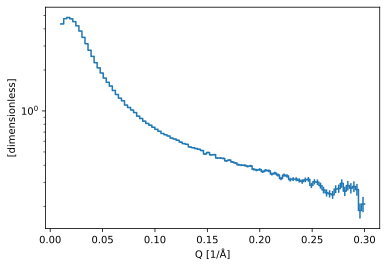

In [4]:
(da,) = results.values()
da.plot(norm="log")